In [ ]:
import os
from pathlib import Path
import time
import copy
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    log_loss,
    )
import joblib
from joblib import Parallel, delayed
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import gc
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from catboost import CatBoostClassifier, Pool
import shap
from torch import Tensor
from typing import Tuple
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold

C:\Users\vihaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [ ]:
PROJECT_ROOT = Path.cwd()
KAGGLE_INPUT = Path('/kaggle/input')
KAGGLE_WORKING = Path('/kaggle/working')

DATA_DIR_CANDIDATES = [
    Path(os.environ['CIC_IDS_DATA_DIR']) if os.environ.get('CIC_IDS_DATA_DIR') else None,
    PROJECT_ROOT,
    PROJECT_ROOT / 'datasets',
    KAGGLE_INPUT,
    KAGGLE_WORKING,
]
DATA_DIR_CANDIDATES = [p for p in DATA_DIR_CANDIDATES if p is not None]
OUTPUT_DIR = KAGGLE_WORKING if KAGGLE_WORKING.exists() else PROJECT_ROOT
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def find_data_file(filename: str) -> Path:
    for base in DATA_DIR_CANDIDATES:
        candidate = base / filename
        if candidate.exists():
            return candidate
    searched = '\n'.join(str(p / filename) for p in DATA_DIR_CANDIDATES)
    raise FileNotFoundError(f"Could not find {filename}. Searched:\n{searched}")


def artifact_path(filename: str) -> Path:
    return OUTPUT_DIR / filename

print('Project root:', PROJECT_ROOT)
print('Output dir:', OUTPUT_DIR)
for name in ['combined_train.csv', 'combined_val.csv', 'combined_supplement.csv', 'combined_test.csv']:
    try:
        print(f'{name}:', find_data_file(name))
    except FileNotFoundError as exc:
        print(str(exc).split('\n')[0])


Project root: c:\Users\vihaa\OneDrive\Documents\IPD-IDS
Output dir: c:\Users\vihaa\OneDrive\Documents\IPD-IDS
combined_train.csv: c:\Users\vihaa\OneDrive\Documents\IPD-IDS\combined_train.csv
combined_val.csv: c:\Users\vihaa\OneDrive\Documents\IPD-IDS\combined_val.csv
combined_supplement.csv: c:\Users\vihaa\OneDrive\Documents\IPD-IDS\combined_supplement.csv
combined_test.csv: c:\Users\vihaa\OneDrive\Documents\IPD-IDS\combined_test.csv


In [ ]:
# Global configuration. Edit values here; downstream cells read from these names.

# Reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True


def reset_seeds(seed: int) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


# Ablation variants. All variants are run in one pass.
VAE_VARIANTS = ("full", "no_time_adv", "no_student")

# Variant toggles (set per variant by apply_variant_settings).
VAE_VARIANT_NAME = None
USE_TIME_ADVERSARIAL = True
USE_STUDENT_T_LOSS = True

# Data
WINDOW_SIZE = 30
BATCH_SIZE = 4096 * 2

# Model
LATENT_DIM = 5
CONV_CHANNELS = 32
KERNEL_SIZE = 3

# Loss weights
BASE_RECON_STUDENT_WEIGHT = 0.4
BASE_RECON_MSE_WEIGHT = 0.2
KLD_WEIGHT = 0.4

# Training
EPOCHS = 30
AE_PRETRAIN_EPOCHS = 0
BETA_MAX = KLD_WEIGHT
BETA_WARMUP_EPOCHS = 8
FREE_BITS = 0.02
DF_DEG = 3.0
VAE_WEIGHT_DECAY = 5e-4

# Adversarial temporal regularization
BASE_ADV_LOSS_WEIGHT = 0.2
BASE_TIME_BIN_ADV_LOSS_WEIGHT = 0.20
TIME_BIN_ADV_BINS = 8
ADV_SEQ_LEN = 8
DISC_HIDDEN_DIM = 64
DISC_N_LAYERS = 2
DISC_LR = 2e-4
BASE_DISC_STEPS_PER_BATCH = 2
DISC_CHUNK_SIZE = 1024

# Active weights (set per variant)
RECON_STUDENT_WEIGHT = BASE_RECON_STUDENT_WEIGHT
RECON_MSE_WEIGHT = BASE_RECON_MSE_WEIGHT
ADV_LOSS_WEIGHT = BASE_ADV_LOSS_WEIGHT
TIME_BIN_ADV_LOSS_WEIGHT = BASE_TIME_BIN_ADV_LOSS_WEIGHT
DISC_STEPS_PER_BATCH = BASE_DISC_STEPS_PER_BATCH


def apply_variant_settings(variant_name: str) -> None:
    global VAE_VARIANT_NAME, USE_TIME_ADVERSARIAL, USE_STUDENT_T_LOSS
    global RECON_STUDENT_WEIGHT, RECON_MSE_WEIGHT
    global ADV_LOSS_WEIGHT, TIME_BIN_ADV_LOSS_WEIGHT, DISC_STEPS_PER_BATCH

    if variant_name not in VAE_VARIANTS:
        raise ValueError(f"Unknown variant: {variant_name}")

    VAE_VARIANT_NAME = variant_name
    USE_TIME_ADVERSARIAL = variant_name != "no_time_adv"
    USE_STUDENT_T_LOSS = variant_name != "no_student"

    RECON_STUDENT_WEIGHT = BASE_RECON_STUDENT_WEIGHT
    RECON_MSE_WEIGHT = BASE_RECON_MSE_WEIGHT
    ADV_LOSS_WEIGHT = BASE_ADV_LOSS_WEIGHT
    TIME_BIN_ADV_LOSS_WEIGHT = BASE_TIME_BIN_ADV_LOSS_WEIGHT
    DISC_STEPS_PER_BATCH = BASE_DISC_STEPS_PER_BATCH

    if not USE_TIME_ADVERSARIAL:
        ADV_LOSS_WEIGHT = 0.0
        TIME_BIN_ADV_LOSS_WEIGHT = 0.0
        DISC_STEPS_PER_BATCH = 0

    if not USE_STUDENT_T_LOSS:
        RECON_STUDENT_WEIGHT = 0.0
        RECON_MSE_WEIGHT = 1.0


# DataLoader. Keep workers at 0 on Windows to avoid PyTorch shared-memory mapping errors.
_NUM_WORKERS = 0
_PIN_MEMORY = torch.cuda.is_available()

print("Config loaded")
print(f"  SEED={SEED}  VARIANTS={', '.join(VAE_VARIANTS)}")
print(f"  WINDOW_SIZE={WINDOW_SIZE}  BATCH_SIZE={BATCH_SIZE}  LATENT_DIM={LATENT_DIM}")
print(f"  EPOCHS={EPOCHS}  BETA_MAX={BETA_MAX:.2f}  BETA_WARMUP={BETA_WARMUP_EPOCHS}")
print(f"  ADV_LOSS_WEIGHT={BASE_ADV_LOSS_WEIGHT}  TIME_BIN_ADV={BASE_TIME_BIN_ADV_LOSS_WEIGHT}  ADV_SEQ_LEN={ADV_SEQ_LEN}  DISC_STEPS={BASE_DISC_STEPS_PER_BATCH}")
print(f"  DISC hidden={DISC_HIDDEN_DIM}  layers={DISC_N_LAYERS}  chunk={DISC_CHUNK_SIZE}")
print(f"  workers={_NUM_WORKERS}  pin_memory={_PIN_MEMORY}")

Config loaded
  SEED=42  VARIANTS=full, no_time_adv, no_student
  WINDOW_SIZE=30  BATCH_SIZE=8192  LATENT_DIM=5
  EPOCHS=30  BETA_MAX=0.40  BETA_WARMUP=8
  ADV_LOSS_WEIGHT=0.2  TIME_BIN_ADV=0.2  ADV_SEQ_LEN=8  DISC_STEPS=2
  DISC hidden=64  layers=2  chunk=1024
  workers=0  pin_memory=True


In [ ]:
train_path = find_data_file('combined_train.csv')
df = pd.read_csv(train_path)
print(train_path)
print(df.shape)
df.head()


c:\Users\vihaa\OneDrive\Documents\IPD-IDS\combined_train.csv
(2097168, 78)


,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,0,0,0,0,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,0,0,0,0,0,0,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,0,0,0,0,0,0,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,0,0,0,0,0,0,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,0,0,0,0,0,0,0,0,0.0,0.0,...,0,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [ ]:
df.isna().sum()

Protocol           0
Flow Duration      0
Tot Fwd Pkts       0
Tot Bwd Pkts       0
TotLen Fwd Pkts    0
                  ..
Idle Mean          0
Idle Std           0
Idle Max           0
Idle Min           0
Label              0
Length: 78, dtype: int64

In [ ]:
X = df.drop(columns=['Label']).copy()
y = df['Label'].copy()

In [ ]:
del df
gc.collect()

20

In [ ]:
# one-hot encode Protocol
X = pd.get_dummies(
    X,
    columns=["Protocol"],
    prefix="Protocol",
    drop_first=False
)

# remove Protocol_0 column
X.drop(columns=["Protocol_0"], inplace=True, errors="ignore")

In [ ]:
X.shape

(2097168, 78)

In [ ]:
y = y.ravel() if y.ndim > 1 else y
le = LabelEncoder()
y = le.fit_transform(y)
label_encoder_path = artifact_path('label_encoder.joblib')
joblib.dump(le, label_encoder_path)
print(f'Saved label encoder to {label_encoder_path}')


Saved label encoder to c:\Users\vihaa\OneDrive\Documents\IPD-IDS\label_encoder.joblib


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 50))

X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index,
)

min_max_mapping = pd.DataFrame({
    'column': X.columns,
    'min': scaler.data_min_,
    'max': scaler.data_max_,
})
min_max_path = artifact_path('column_min_max_mapping.csv')
min_max_mapping.to_csv(min_max_path, index=False)
print(f'Saved min/max mapping for {len(min_max_mapping)} columns to {min_max_path}')
min_max_mapping.head()


Saved min/max mapping for 78 columns to c:\Users\vihaa\OneDrive\Documents\IPD-IDS\column_min_max_mapping.csv


,column,min,max
0,Flow Duration,-9.190110e+11,120000000.0
1,Tot Fwd Pkts,0.000000e+00,9021.0
2,Tot Bwd Pkts,0.000000e+00,19181.0
3,TotLen Fwd Pkts,0.000000e+00,8737314.0
4,TotLen Bwd Pkts,0.000000e+00,27905234.0


# Checking Normality

In [ ]:
def prepare_balanced_dataset(X_full, y_full, sample_size_per_class=10000, random_state=SEED):
    X_full = pd.DataFrame(X_full, columns=X_full.columns)
    y_full = pd.Series(y_full)

    classes = pd.unique(y_full)

    X_list = []
    y_list = []

    for cls in classes:
        cls_idx = y_full[y_full == cls].index
        sample_size = min(sample_size_per_class, len(cls_idx))
        cls_sample = cls_idx.to_series().sample(sample_size, random_state=random_state)
        X_list.append(X_full.loc[cls_sample])
        y_list.append(y_full.loc[cls_sample])

    sample_X = pd.concat(X_list, ignore_index=True)
    sample_y = pd.concat(y_list, ignore_index=True)

    return sample_X, sample_y, classes


sample_X, sample_y, classes = prepare_balanced_dataset(
    X,
    y,
    sample_size_per_class=10000
)

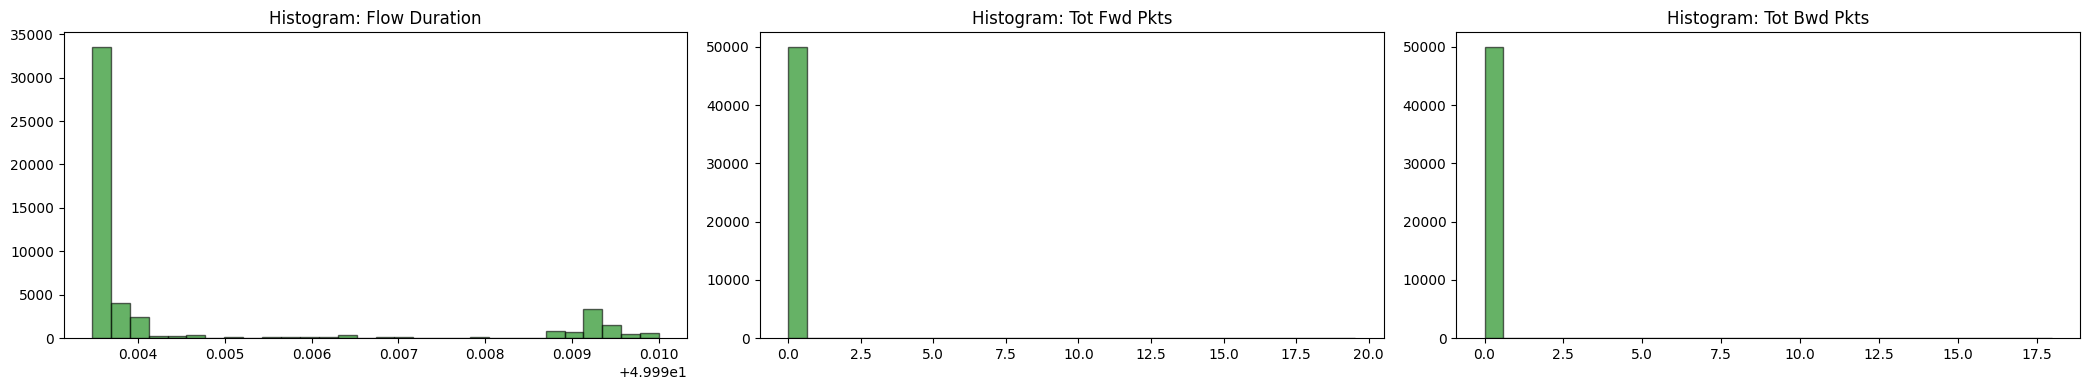

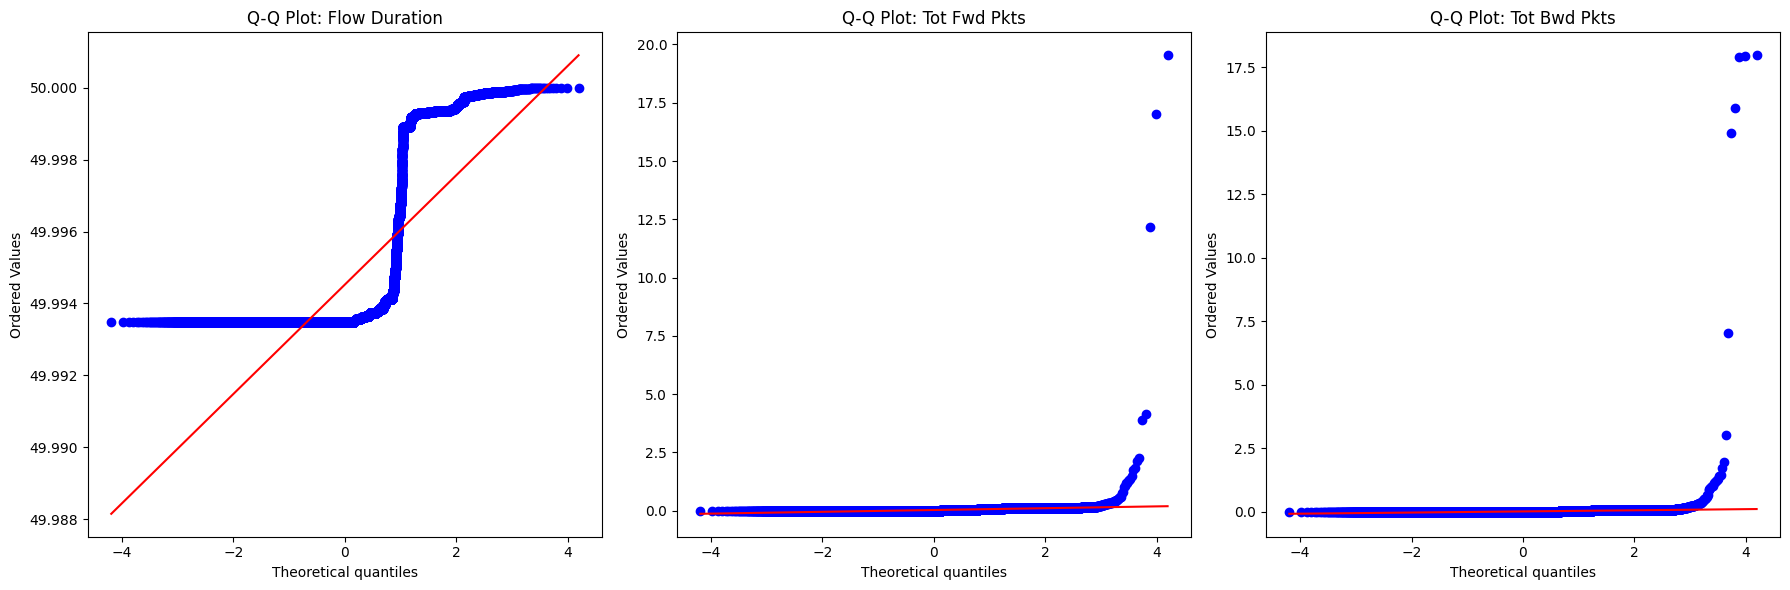

Normal columns (p >= 0.05): ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
Normal columns (p >= 0.05): ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']


C:\Users\vihaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 50000.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\vihaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
def check_normality(sample, plot_first=True, alpha=0.05, bins=30):
    normal_columns = []
    nonnormal_columns = []
    numeric_cols = sample.columns
    
    if plot_first:
        plot_cols = numeric_cols[:3]
        n_plots = len(plot_cols)
        
        if n_plots > 0:
            fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 4))
            if n_plots == 1:
                axes = [axes]
            
            for i, col in enumerate(plot_cols):
                data = sample[col].dropna()
                axes[i].hist(data, bins=bins, alpha=0.6, color='g', edgecolor='k')
                axes[i].set_title(f'Histogram: {col}')
            
            plt.tight_layout()
            plt.show()
            
            fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 6))
            if n_plots == 1:
                axes = [axes]
            
            for i, col in enumerate(plot_cols):
                data = sample[col].dropna()
                stats.probplot(data, dist="norm", plot=axes[i])
                axes[i].set_title(f'Q-Q Plot: {col}')
            
            plt.tight_layout()
            plt.show()
    
    for col in numeric_cols:
        data = sample[col].dropna()
        shapiro_stat, shapiro_p = stats.shapiro(data)
        if shapiro_p >= alpha:
            normal_columns.append(col)
        else:
            nonnormal_columns.append(col)
    
    print(f"Normal columns (p >= {alpha}):", normal_columns)
    print(f"Normal columns (p >= {alpha}):", normal_columns)

check_normality(sample_X)

# Catboost Feature Finding

In [ ]:
import os
CATBOOST_TASK_TYPE = 'GPU' if torch.cuda.is_available() else 'CPU'


def with_catboost_device(params):
    params = params.copy()
    params['task_type'] = CATBOOST_TASK_TYPE
    if CATBOOST_TASK_TYPE == 'GPU':
        params['devices'] = '0'
    return params


def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 3, 12),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'loss_function': 'MultiClass',
        'verbose': False,
        'random_seed': SEED
    }

    model = CatBoostClassifier(**with_catboost_device(params))

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    scores = cross_val_score(
        model,
        sample_X,
        sample_y,
        cv=cv,
        scoring='neg_log_loss',
        n_jobs=1
    )

    return -scores.mean()


def get_top_features_optuna(sample_X, sample_y, n_trials=1, importance_threshold=0.95, shap_batch_size=512):
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials, n_jobs=1)

    best_params = study.best_params
    best_params.update({
        'loss_function': 'MultiClass',
        'verbose': False,
        'random_seed': SEED
    })

    model = CatBoostClassifier(**with_catboost_device(best_params))
    model.fit(sample_X, sample_y)

    explainer = shap.TreeExplainer(model)
    feature_total = sample_X.shape[1]
    shap_sum = np.zeros(feature_total, dtype=np.float64)
    sample_count = 0

    for start_idx in range(0, len(sample_X), shap_batch_size):
        batch_X = sample_X.iloc[start_idx:start_idx + shap_batch_size]
        shap_values = explainer.shap_values(batch_X)

        if isinstance(shap_values, list):
            batch_abs = np.mean([np.abs(sv) for sv in shap_values], axis=(0, 1))
        else:
            batch_abs = np.mean(np.abs(shap_values), axis=(0, 2))

        shap_sum += batch_abs * len(batch_X)
        sample_count += len(batch_X)

    mean_abs_shap = shap_sum / sample_count

    importances = pd.DataFrame({
        'feature': sample_X.columns,
        'importance': mean_abs_shap
    }).sort_values(by='importance', ascending=False)

    threshold = importances['importance'].sum() * importance_threshold
    importances['cumsum'] = importances['importance'].cumsum()

    top_features = importances[
        importances['cumsum'] <= threshold
    ]['feature']

    return top_features.tolist(), model, study.best_params


# Load or compute top features
top_features_path = artifact_path('top_features.joblib')
best_params_path = artifact_path('best_params.joblib')

if top_features_path.exists() and best_params_path.exists():
    print(f'Loading cached top features from {top_features_path}')
    top_features = joblib.load(top_features_path)
    best_params = joblib.load(best_params_path)
    print("Top features:", top_features)
    print("Best parameters:", best_params)
else:
    print("Running CatBoost/SHAP feature selection (this will take a few minutes)...")
    top_features, best_model, best_params = get_top_features_optuna(
        sample_X,
        sample_y,
        n_trials=20,
        shap_batch_size=512
    )
    
    joblib.dump(top_features, top_features_path)
    joblib.dump(best_params, best_params_path)
    print(f'Saved top features to {top_features_path}')
    print(f'Saved best params to {best_params_path}')
    print("Top features:", top_features)
    print("Best parameters:", best_params)

Loading cached top features from c:\Users\vihaa\OneDrive\Documents\IPD-IDS\top_features.joblib
Top features: ['Flow Pkts/s', 'Fwd Seg Size Min', 'Init Bwd Win Byts', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Flow IAT Std', 'Init Fwd Win Byts', 'Fwd Pkt Len Std', 'Pkt Len Max', 'ACK Flag Cnt', 'Flow Byts/s', 'Fwd Header Len', 'Tot Bwd Pkts', 'Fwd Pkt Len Max', 'Bwd Header Len', 'Pkt Len Std', 'Tot Fwd Pkts', 'Bwd IAT Min', 'Bwd IAT Mean', 'Fwd IAT Std', 'PSH Flag Cnt', 'Pkt Len Var']
Best parameters: {'iterations': 508, 'learning_rate': 0.26246011543788544, 'depth': 6, 'l2_leaf_reg': 3.2919498955827704, 'border_count': 193}


In [ ]:
X = X[top_features]

gc.collect()

# Load and normalize validation data using training min/max
val_path = find_data_file('combined_val.csv')
df_val = pd.read_csv(val_path)
X_val = df_val.drop(columns=['Label']).copy()

# One-hot encode Protocol
X_val = pd.get_dummies(X_val, columns=['Protocol'], prefix='Protocol', drop_first=False)
X_val.drop(columns=['Protocol_0'], inplace=True, errors='ignore')

# Select only top features
X_val = X_val.reindex(columns=top_features, fill_value=0)

# Normalize using training min/max
min_max_df = pd.read_csv(artifact_path('column_min_max_mapping.csv'))
min_max_dict = {row['column']: (row['min'], row['max']) for _, row in min_max_df.iterrows()}
for col in X_val.columns:
    col_min, col_max = min_max_dict[col]
    if col_max - col_min != 0:
        X_val[col] = ((X_val[col] - col_min) / (col_max - col_min)) * 50
    else:
        X_val[col] = 0

print(f'Validation path: {val_path}')
print(f'Validation data shape: {X_val.shape}')


Validation path: c:\Users\vihaa\OneDrive\Documents\IPD-IDS\combined_val.csv
Validation data shape: (613113, 22)


# VAE Implmentation

In [ ]:
def make_windows(X_array: np.ndarray, window_size: int = WINDOW_SIZE) -> np.ndarray:
    """
    Build sliding windows of consecutive flow records.
    Input:  X_array shape (N, n_features)
    Output: windows shape (N - window_size + 1, window_size, n_features)
    """
    X_array = np.asarray(X_array)
    N = len(X_array)
    if N < window_size:
        raise ValueError(f'Need at least {window_size} rows to build one window, got {N}')
    return np.stack([X_array[i : i + window_size] for i in range(N - window_size + 1)])


# Training data
X_raw      = X.values.astype(np.float64)
X_windowed = make_windows(X_raw)
y_windowed = pd.Series(y[WINDOW_SIZE - 1:]).reset_index(drop=True)

time_bin_positions = np.arange(len(X_windowed))
time_bin_edges = np.linspace(0, len(X_windowed), TIME_BIN_ADV_BINS + 1)
time_bin_labels = np.searchsorted(time_bin_edges[1:-1], time_bin_positions, side="right").astype(np.int64)

dataset    = TensorDataset(
    torch.tensor(X_windowed, dtype=torch.float64),
    torch.tensor(time_bin_labels, dtype=torch.long),
)
train_generator = torch.Generator()
train_generator.manual_seed(SEED)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_generator,
    num_workers=_NUM_WORKERS,
    pin_memory=_PIN_MEMORY,
    persistent_workers=_NUM_WORKERS > 0,
)

# Validation data
X_val_raw      = X_val.values.astype(np.float64)
X_val_windowed = make_windows(X_val_raw)

val_dataset    = TensorDataset(torch.tensor(X_val_windowed, dtype=torch.float64))
val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=_NUM_WORKERS,
    pin_memory=_PIN_MEMORY,
    persistent_workers=_NUM_WORKERS > 0,
)

n_features = X_windowed.shape[2]
latent_dim = LATENT_DIM

print(f'Train windows:      {X_windowed.shape}')
print(f'Validation windows: {X_val_windowed.shape}')
print(f'n_features={n_features}  latent_dim={latent_dim}')

Train windows:      (2097139, 30, 22)
Validation windows: (613084, 30, 22)
n_features=22  latent_dim=5


In [ ]:
class ConvAttentionBlock(nn.Module):
    def __init__(
        self,
        embed_dim: int,
        num_heads: int = 4,
        dropout: float = 0.1,
        conv_kernel_size: int = 3,
    ):
        super().__init__()
        if embed_dim % num_heads != 0:
            raise ValueError('embed_dim must be divisible by num_heads')

        conv_padding = conv_kernel_size // 2
        self.local_conv = nn.Sequential(
            nn.Conv1d(
                in_channels=embed_dim,
                out_channels=embed_dim,
                kernel_size=conv_kernel_size,
                padding=conv_padding,
                groups=embed_dim,
            ),
            nn.GELU(),
            nn.Conv1d(embed_dim, embed_dim, kernel_size=1),
        ).double()
        self.norm_local = nn.LayerNorm(embed_dim).double()
        self.self_attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        ).double()
        self.norm_attention = nn.LayerNorm(embed_dim).double()
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim),
        ).double()
        self.norm_ffn = nn.LayerNorm(embed_dim).double()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: Tensor) -> Tensor:
        local_features = self.local_conv(x.transpose(1, 2)).transpose(1, 2)
        x = self.norm_local(x + local_features)
        attention_features, _ = self.self_attention(x, x, x, need_weights=False)
        x = self.norm_attention(x + self.dropout(attention_features))
        return self.norm_ffn(x + self.dropout(self.ffn(x)))


class Encoder(nn.Module):
    def __init__(
        self,
        n_features: int,
        latent_dim: int,
        conv_channels: int = 128,
        kernel_size: int = 3,
    ):
        super().__init__()
        self.kernel_size = kernel_size
        self.conv1 = nn.Conv1d(
            in_channels=n_features,
            out_channels=conv_channels,
            kernel_size=kernel_size,
            padding=0,
        ).double()
        self.relu = nn.ReLU()
        self.attention = ConvAttentionBlock(embed_dim=conv_channels)
        self.lstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=conv_channels,
            batch_first=True,
        ).double()
        self.fc_mu = nn.Linear(conv_channels, latent_dim).double()
        self.fc_logvar = nn.Linear(conv_channels, latent_dim).double()

    def forward(self, x: Tensor) -> Tuple[Tensor, Tensor]:
        x = x.permute(0, 2, 1)
        x = F.pad(x, (self.kernel_size - 1, 0))
        x = self.relu(self.conv1(x))
        x = x.permute(0, 2, 1)
        x = self.attention(x)
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


In [ ]:
class Decoder(nn.Module):
    def __init__(
        self,
        n_features: int,
        latent_dim: int,
        conv_channels: int = 128,
        kernel_size: int = 3,
        output_window_size: int = WINDOW_SIZE,
    ):
        super().__init__()
        self.kernel_size = kernel_size
        self.output_window_size = output_window_size
        self.fc = nn.Linear(latent_dim, output_window_size * conv_channels).double()
        self.lstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=conv_channels,
            batch_first=True,
        ).double()
        self.deconv1 = nn.Conv1d(
            in_channels=conv_channels,
            out_channels=n_features,
            kernel_size=kernel_size,
            padding=0,
        ).double()

    def forward(self, z: Tensor) -> Tensor:
        z = self.fc(z)
        z = z.view(z.size(0), self.output_window_size, -1)
        x, _ = self.lstm(z)
        x = x.permute(0, 2, 1)
        x = F.pad(x, (self.kernel_size - 1, 0))
        x = self.deconv1(x)
        x = x.permute(0, 2, 1)
        return x


In [ ]:
class VAE(nn.Module):
    def __init__(
        self,
        n_features: int,
        latent_dim: int,
        conv_channels: int = 32,
        kernel_size: int = 3,
        window_size: int = WINDOW_SIZE,
    ):
        super().__init__()
        self.encoder = Encoder(n_features, latent_dim, conv_channels, kernel_size)
        self.decoder = Decoder(n_features, latent_dim, conv_channels, kernel_size, output_window_size=window_size)

    def reparameterize(self, mu: Tensor, logvar: Tensor, deterministic: bool = False) -> Tensor:
        if deterministic:
            return mu
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x: Tensor, deterministic: bool = False) -> Tuple[Tensor, Tensor, Tensor]:
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar, deterministic=deterministic)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar


In [ ]:
def student_t_loss(recon_x: Tensor, x: Tensor, df: float = DF_DEG) -> Tensor:
    recon_last = recon_x[:, -1, :]
    x_last     = x[:, -1, :]
    diff       = recon_last - x_last
    return torch.mean(torch.log1p((diff * diff) / df))


def mse_loss_last(recon_x: Tensor, x: Tensor) -> Tensor:
    diff = recon_x[:, -1, :] - x[:, -1, :]
    return torch.mean(diff * diff)


def kld_only_loss(mu: Tensor, logvar: Tensor) -> Tensor:
    return (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp())).mean()


def vae_loss(
    recon_x : Tensor,
    x       : Tensor,
    mu      : Tensor,
    logvar  : Tensor,
    beta    : float = KLD_WEIGHT,
    df      : float = DF_DEG,
    free_bits: float = 0.0,
) -> Tuple[Tensor, Tensor, Tensor, Tensor]:
    student_loss = student_t_loss(recon_x, x, df=df)
    mse_loss     = mse_loss_last(recon_x, x)
    recon_loss   = RECON_STUDENT_WEIGHT * student_loss + RECON_MSE_WEIGHT * mse_loss
    kld_per_dim  = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    raw_kld      = kld_per_dim.mean()
    kld_loss     = torch.clamp(kld_per_dim, min=free_bits).mean() if free_bits > 0 else raw_kld
    total_loss   = recon_loss + beta * kld_loss
    return total_loss, recon_loss, raw_kld, mse_loss

In [ ]:
def _all_subsequences(z: Tensor, seq_len: int) -> Tensor:
    """
    Build all contiguous latent subsequences of length seq_len.
    Input:  z with shape (batch, latent_dim)
    Output: tensor with shape (batch - seq_len + 1, seq_len, latent_dim)
    """
    return z.unfold(0, seq_len, 1).permute(0, 2, 1).contiguous()


class TemporalDiscriminator(nn.Module):
    """LSTM discriminator for chronological-vs-shuffled latent sequences."""

    def __init__(
        self,
        latent_dim: int,
        hidden_dim: int = DISC_HIDDEN_DIM,
        num_layers: int = DISC_N_LAYERS,
    ):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=latent_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0,
        ).double()
        mlp_in = hidden_dim * 2
        self.mlp = nn.Sequential(
            nn.Linear(mlp_in, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim // 2, 1),
        ).double()

    def forward(self, seqs: Tensor) -> Tensor:
        out, (h_n, _) = self.lstm(seqs)
        last_hidden = h_n[-1]
        mean_pooled = out.mean(dim=1)
        return self.mlp(torch.cat([last_hidden, mean_pooled], dim=-1)).squeeze(-1)

    def forward_chunked(self, seqs: Tensor, chunk_size: int = DISC_CHUNK_SIZE) -> Tensor:
        chunks = seqs.split(chunk_size, dim=0)
        return torch.cat([self.forward(c) for c in chunks], dim=0)


class TimeBinDiscriminator(nn.Module):
    """Predicts coarse chronological bins from each latent vector."""

    def __init__(self, latent_dim: int, n_bins: int = TIME_BIN_ADV_BINS, hidden_dim: int = DISC_HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, n_bins),
        ).double()

    def forward(self, z: Tensor) -> Tensor:
        return self.net(z)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def init_training_state() -> None:
    global vae, optimizer, scheduler, discriminator, disc_optimizer, adv_dataloader
    global time_discriminator, time_disc_optimizer
    global best_val_loss, best_vae_state, best_disc_state, best_time_disc_state, best_epoch
    global all_recon_errors, all_latent_norms, training_history

    vae = VAE(
        n_features,
        latent_dim,
        conv_channels=CONV_CHANNELS,
        kernel_size=KERNEL_SIZE,
    ).double().to(device)
    optimizer = optim.AdamW(vae.parameters(), lr=1e-3, weight_decay=VAE_WEIGHT_DECAY)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=1, eta_min=1e-5)

    discriminator = TemporalDiscriminator(latent_dim=latent_dim).to(device)
    disc_optimizer = optim.AdamW(discriminator.parameters(), lr=DISC_LR, weight_decay=1e-4)

    time_discriminator = TimeBinDiscriminator(latent_dim=latent_dim).to(device)
    time_disc_optimizer = optim.AdamW(time_discriminator.parameters(), lr=DISC_LR, weight_decay=1e-4)

    adv_dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=_NUM_WORKERS,
        pin_memory=_PIN_MEMORY,
        persistent_workers=_NUM_WORKERS > 0,
    )

    best_val_loss = float("inf")
    best_vae_state = None
    best_disc_state = None
    best_time_disc_state = None
    best_epoch = -1

    vae.train()
    discriminator.train()
    time_discriminator.train()
    all_recon_errors = []
    all_latent_norms = []
    training_history = []

In [ ]:
def train_discriminator_step(x_adv, time_bin_adv):
    zero = torch.tensor(0.0, dtype=torch.double, device=device)
    losses = {
        "chron_disc_loss": zero,
        "time_bin_disc_loss": zero,
    }
    if not USE_TIME_ADVERSARIAL or DISC_STEPS_PER_BATCH <= 0:
        return losses

    for _ in range(DISC_STEPS_PER_BATCH):
        if ADV_LOSS_WEIGHT > 0 and x_adv.size(0) >= ADV_SEQ_LEN:
            disc_optimizer.zero_grad()
            with torch.no_grad():
                _, mu_adv_d, _ = vae(x_adv, deterministic=False)
            mu_adv_d = mu_adv_d.detach()

            perm_d = torch.randperm(mu_adv_d.size(0), device=device)
            z_shuffled_d = mu_adv_d[perm_d]

            real_seqs = _all_subsequences(mu_adv_d, ADV_SEQ_LEN)
            fake_seqs = _all_subsequences(z_shuffled_d, ADV_SEQ_LEN)

            logit_real = discriminator.forward_chunked(real_seqs)
            logit_fake = discriminator.forward_chunked(fake_seqs)
            chron_disc_loss = (
                F.binary_cross_entropy_with_logits(logit_real, torch.ones_like(logit_real))
                + F.binary_cross_entropy_with_logits(logit_fake, torch.zeros_like(logit_fake))
            )
            chron_disc_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=5.0)
            disc_optimizer.step()
            losses["chron_disc_loss"] = chron_disc_loss.detach()

        if TIME_BIN_ADV_LOSS_WEIGHT > 0:
            time_disc_optimizer.zero_grad()
            with torch.no_grad():
                _, mu_time_d, _ = vae(x_adv, deterministic=False)
            time_logits = time_discriminator(mu_time_d.detach())
            time_bin_disc_loss = F.cross_entropy(time_logits, time_bin_adv)
            time_bin_disc_loss.backward()
            torch.nn.utils.clip_grad_norm_(time_discriminator.parameters(), max_norm=5.0)
            time_disc_optimizer.step()
            losses["time_bin_disc_loss"] = time_bin_disc_loss.detach()

    return losses

In [ ]:
def train_vae_batch(x, x_adv, epoch_beta):
    optimizer.zero_grad()

    recon_x, mu, logvar = vae(x, deterministic=False)
    loss, recon_component, kld_component, mse_component = vae_loss(
        recon_x, x, mu, logvar,
        beta=epoch_beta,
        df=DF_DEG,
        free_bits=FREE_BITS,
    )

    if USE_TIME_ADVERSARIAL and ADV_LOSS_WEIGHT > 0 and x_adv.size(0) >= ADV_SEQ_LEN:
        _, mu_adv_enc, _ = vae(x_adv, deterministic=False)
        perm_enc = torch.randperm(mu_adv_enc.size(0), device=device)
        z_shuffled_enc = mu_adv_enc[perm_enc]
        shuffled_seqs = _all_subsequences(z_shuffled_enc, ADV_SEQ_LEN)
        logit_shuffled = discriminator.forward_chunked(shuffled_seqs)
        chron_adv_enc_loss = F.binary_cross_entropy_with_logits(
            logit_shuffled, torch.ones_like(logit_shuffled)
        )
    else:
        chron_adv_enc_loss = torch.tensor(0.0, dtype=torch.double, device=device)

    if USE_TIME_ADVERSARIAL and TIME_BIN_ADV_LOSS_WEIGHT > 0:
        _, mu_time_enc, _ = vae(x_adv, deterministic=False)
        time_logits = time_discriminator(mu_time_enc)
        time_log_probs = F.log_softmax(time_logits, dim=1)
        time_bin_adv_enc_loss = -time_log_probs.mean(dim=1).mean()
    else:
        time_bin_adv_enc_loss = torch.tensor(0.0, dtype=torch.double, device=device)

    total_vae_loss = (
        loss
        + ADV_LOSS_WEIGHT * chron_adv_enc_loss
        + TIME_BIN_ADV_LOSS_WEIGHT * time_bin_adv_enc_loss
    )

    total_vae_loss.backward()
    torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=5.0)
    optimizer.step()

    n = x.size(0)
    return {
        'n': n,
        'loss': loss.item(),
        'recon_loss': recon_component.item(),
        'kld_loss': kld_component.item(),
        'mse_loss': mse_component.item(),
        'chron_adv_enc_loss': chron_adv_enc_loss.item(),
        'time_bin_adv_enc_loss': time_bin_adv_enc_loss.item(),
    }

In [ ]:
def validate_vae_epoch(epoch_beta):
    vae.eval()
    val_loss = val_samples = val_recon_loss = val_kld_loss = val_mse_loss = 0.0

    with torch.no_grad():
        for batch in val_dataloader:
            x_val = batch[0].to(device, non_blocking=True)
            recon_x_val, mu_val, logvar_val = vae(x_val, deterministic=True)
            loss_val, recon_val, kld_val, mse_val = vae_loss(
                recon_x_val, x_val, mu_val, logvar_val,
                beta=epoch_beta,
                df=DF_DEG,
                free_bits=FREE_BITS,
            )
            n_v = x_val.size(0)
            val_loss += loss_val.item() * n_v
            val_samples += n_v
            val_recon_loss += recon_val.item() * n_v
            val_kld_loss += kld_val.item() * n_v
            val_mse_loss += mse_val.item() * n_v

    vae.train()
    discriminator.train()
    return {
        'val_loss': val_loss / val_samples,
        'val_recon_loss': val_recon_loss / val_samples,
        'val_kld_loss': val_kld_loss / val_samples,
        'val_mse_loss': val_mse_loss / val_samples,
    }


In [ ]:
def train_vae() -> None:
    global best_val_loss, best_epoch, best_vae_state, best_disc_state, best_time_disc_state

    for epoch in range(EPOCHS):
        total_loss = 0.0
        total_samples = 0
        total_recon_loss = 0.0
        total_kld_loss = 0.0
        total_mse_loss = 0.0
        total_chron_adv_enc_loss = 0.0
        total_time_bin_adv_enc_loss = 0.0
        total_chron_disc_loss = 0.0
        total_time_bin_disc_loss = 0.0

        epoch_beta = BETA_MAX * min(1.0, (epoch + 1) / BETA_WARMUP_EPOCHS)

        for batch, adv_batch in zip(dataloader, adv_dataloader):
            x = batch[0].to(device, non_blocking=True)
            x_adv = adv_batch[0].to(device, non_blocking=True)
            time_bin_adv = adv_batch[1].to(device, non_blocking=True)

            disc_losses = train_discriminator_step(x_adv, time_bin_adv)
            batch_metrics = train_vae_batch(x, x_adv, epoch_beta)
            n = batch_metrics["n"]

            total_loss += batch_metrics["loss"] * n
            total_samples += n
            total_recon_loss += batch_metrics["recon_loss"] * n
            total_kld_loss += batch_metrics["kld_loss"] * n
            total_mse_loss += batch_metrics["mse_loss"] * n
            total_chron_adv_enc_loss += batch_metrics["chron_adv_enc_loss"] * n
            total_time_bin_adv_enc_loss += batch_metrics["time_bin_adv_enc_loss"] * n
            total_chron_disc_loss += disc_losses["chron_disc_loss"].item() * n
            total_time_bin_disc_loss += disc_losses["time_bin_disc_loss"].item() * n

        avg_loss = total_loss / total_samples
        avg_recon_loss = total_recon_loss / total_samples
        avg_kld_loss = total_kld_loss / total_samples
        avg_mse_loss = total_mse_loss / total_samples
        avg_chron_adv_enc_loss = total_chron_adv_enc_loss / total_samples
        avg_time_bin_adv_enc_loss = total_time_bin_adv_enc_loss / total_samples
        avg_chron_disc_loss = total_chron_disc_loss / total_samples
        avg_time_bin_disc_loss = total_time_bin_disc_loss / total_samples

        val_metrics = validate_vae_epoch(epoch_beta)
        avg_val_loss = val_metrics["val_loss"]
        avg_val_recon_loss = val_metrics["val_recon_loss"]
        avg_val_kld_loss = val_metrics["val_kld_loss"]
        avg_val_mse_loss = val_metrics["val_mse_loss"]

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            best_vae_state = copy.deepcopy(vae.state_dict())
            best_disc_state = copy.deepcopy(discriminator.state_dict())
            best_time_disc_state = copy.deepcopy(time_discriminator.state_dict())
            ckpt_marker = "  <-- best"
        else:
            ckpt_marker = ""

        current_lr = optimizer.param_groups[0]["lr"]
        training_history.append({
            "epoch": epoch + 1,
            "train_loss": avg_loss,
            "train_recon_loss": avg_recon_loss,
            "train_mse_loss": avg_mse_loss,
            "train_kld_loss": avg_kld_loss,
            "train_chron_adv_enc_loss": avg_chron_adv_enc_loss,
            "train_time_bin_adv_enc_loss": avg_time_bin_adv_enc_loss,
            "train_chron_disc_loss": avg_chron_disc_loss,
            "train_time_bin_disc_loss": avg_time_bin_disc_loss,
            "val_loss": avg_val_loss,
            "val_recon_loss": avg_val_recon_loss,
            "val_mse_loss": avg_val_mse_loss,
            "val_kld_loss": avg_val_kld_loss,
            "beta": epoch_beta,
            "lr": current_lr,
            "is_best": bool(ckpt_marker),
        })

        print(
            f"Epoch {epoch+1}/{EPOCHS}  "
            f"Train Loss: {avg_loss:.4f} "
            f"(Recon: {avg_recon_loss:.4f}, MSE: {avg_mse_loss:.4f}, "
            f"KLD: {avg_kld_loss:.6f}, Beta: {epoch_beta:.4f})  |  "
            f"Val Loss: {avg_val_loss:.4f} "
            f"(Recon: {avg_val_recon_loss:.4f}, MSE: {avg_val_mse_loss:.4f}, "
            f"KLD: {avg_val_kld_loss:.6f})  |  "
            f"ChronAdv: {avg_chron_adv_enc_loss:.4f}/{avg_chron_disc_loss:.4f}  "
            f"TimeBinAdv: {avg_time_bin_adv_enc_loss:.4f}/{avg_time_bin_disc_loss:.4f}"
            f"{ckpt_marker}"
        )

        scheduler.step()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    if best_vae_state is None:
        raise RuntimeError("No valid VAE checkpoint was captured. Check validation loss for NaN/inf.")

    print(f"\nRestoring best weights from epoch {best_epoch}  (val_loss={best_val_loss:.4f})")
    vae.load_state_dict(best_vae_state)
    discriminator.load_state_dict(best_disc_state)
    if best_time_disc_state is not None:
        time_discriminator.load_state_dict(best_time_disc_state)
    vae.eval()
    discriminator.eval()
    time_discriminator.eval()

In [ ]:
def collect_vae_diagnostics(model, loader):
    recon_errors = []
    latent_norms = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            x_diag = batch[0].to(device, non_blocking=True)
            recon_diag, mu_diag, _ = model(x_diag, deterministic=True)
            recon_errors.append(torch.mean((x_diag - recon_diag) ** 2, dim=(1, 2)).cpu().numpy())
            latent_norms.append(torch.norm(mu_diag, dim=1).cpu().numpy())
    return np.concatenate(recon_errors, axis=0), np.concatenate(latent_norms, axis=0)


def save_vae_artifacts() -> None:
    global all_recon_errors, all_latent_norms

    all_recon_errors, all_latent_norms = collect_vae_diagnostics(vae, val_dataloader)
    np.save(artifact_path(f"reconstruction_errors_{VAE_VARIANT_NAME}.npy"), all_recon_errors)
    np.save(artifact_path(f"latent_norms_{VAE_VARIANT_NAME}.npy"), all_latent_norms)
    pd.DataFrame(training_history).to_csv(
        artifact_path(f"vae_training_history_{VAE_VARIANT_NAME}.csv"),
        index=False,
    )

    vae_path = artifact_path(f"vae_{VAE_VARIANT_NAME}_model.pth")
    torch.save(vae, vae_path)
    print(f"Saved VAE to {vae_path}")

In [ ]:
def load_trained_vae(variant_name=None):
    name = variant_name or VAE_VARIANT_NAME
    if name is None:
        raise ValueError("Variant name is not set.")
    model = torch.load(artifact_path(f"vae_{name}_model.pth"), weights_only=False)
    model.eval()
    return model

In [ ]:
def compress_with_vae(model, X_windowed, batch_size=768, df_deg=3.0):
    device = next(model.encoder.parameters()).device
    X_windowed = np.asarray(X_windowed, dtype=np.float64)
    n_samples = X_windowed.shape[0]
    all_mu = []
    all_student_losses = []
    all_kld_losses = []
    all_mse_losses = []

    model.eval()
    with torch.no_grad():
        for i in range(0, n_samples, batch_size):
            batch = torch.from_numpy(X_windowed[i : i + batch_size]).to(device=device, dtype=torch.double)
            mu, logvar = model.encoder(batch)
            all_mu.append(mu.cpu())

            recon = model.decoder(mu)
            recon_last = recon[:, -1, :]
            batch_last = batch[:, -1, :]
            diff = recon_last - batch_last
            per_row_student = torch.log1p((diff * diff) / df_deg).mean(dim=1)
            per_row_mse = (diff * diff).mean(dim=1)
            all_student_losses.append(per_row_student.cpu())
            all_mse_losses.append(per_row_mse.cpu())

            per_row_kld = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).mean(dim=1)
            all_kld_losses.append(per_row_kld.cpu())
            del batch, mu, logvar, recon

    compressed_cpu = torch.cat(all_mu, dim=0).numpy()
    student_losses = torch.cat(all_student_losses, dim=0).numpy()
    kld_losses = torch.cat(all_kld_losses, dim=0).numpy()
    mse_losses = torch.cat(all_mse_losses, dim=0).numpy()

    compressed_X = pd.DataFrame(
        compressed_cpu,
        columns=[f"latent_{i}" for i in range(compressed_cpu.shape[1])],
    )
    compressed_X["student_loss"] = student_losses
    compressed_X["kld_loss"] = kld_losses
    compressed_X["mse_loss"] = mse_losses

    del all_mu, all_student_losses, all_kld_losses, all_mse_losses
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return compressed_X


def build_df_train(compressed_X, y_windowed):
    df_train = compressed_X.copy()
    df_train["label"] = y_windowed.reset_index(drop=True)
    df_train.reset_index(drop=True, inplace=True)
    return df_train


DEFAULT_COMPRESS_BATCH_SIZE = 768

# Normality of compressed X 

In [ ]:
def run_normality_check_for_compressed(compressed_X, y_windowed, variant_name, sample_size_per_class=10000) -> None:
    print(f"Normality check for variant: {variant_name}")
    sample_X, sample_y, classes = prepare_balanced_dataset(
        compressed_X,
        y_windowed,
        sample_size_per_class=sample_size_per_class,
    )
    check_normality(sample_X)


# Pipeline

In [ ]:
def inference_pipeline(
    X_new,
    y_new,
    vae_path,
    min_max_path,
    label_encoder_path,
    top_features_path,
    batch_size=6144,
    window_size=WINDOW_SIZE,
    device_override=None,
):
    map_location = torch.device(device_override) if device_override is not None else None
    if map_location is None:
        vae = torch.load(vae_path, weights_only=False)
    else:
        vae = torch.load(vae_path, weights_only=False, map_location=map_location)
    vae.eval()
    device = map_location if map_location is not None else next(vae.encoder.parameters()).device
    if map_location is not None:
        vae.to(device)

    min_max_df = pd.read_csv(min_max_path)
    min_max_dict = {row['column']: (row['min'], row['max']) for _, row in min_max_df.iterrows()}
    top_features = joblib.load(top_features_path)

    le = joblib.load(label_encoder_path)
    classes = np.array(le.classes_)
    new_classes = sorted(set(pd.Series(y_new).unique()) - set(classes))
    if new_classes:
        classes = np.concatenate([classes, np.array(new_classes)])
    y_encoded = pd.Series(y_new).map({cls: idx for idx, cls in enumerate(classes)}).to_numpy()

    X_new = pd.get_dummies(X_new, columns=['Protocol'], prefix='Protocol', drop_first=False)
    X_new.drop(columns=['Protocol_0'], inplace=True, errors='ignore')
    X_new = X_new.reindex(columns=top_features, fill_value=0)

    X_normalized = X_new.copy()
    for col in X_normalized.columns:
        col_min, col_max = min_max_dict[col]
        if col_max - col_min != 0:
            X_normalized[col] = ((X_new[col] - col_min) / (col_max - col_min)) * 50
        else:
            X_normalized[col] = 0

    X_array = X_normalized.values.astype(np.float64)
    X_windowed = make_windows(X_array, window_size)
    y_aligned = y_encoded[window_size - 1:]

    n_samples = X_windowed.shape[0]
    all_mu = []
    all_recon_losses = []
    all_kld_losses = []
    all_mse_losses = []
    df_deg = 3.0

    with torch.no_grad():
        for i in range(0, n_samples, batch_size):
            batch = torch.from_numpy(X_windowed[i : i + batch_size]).to(device=device, dtype=torch.double)
            mu, logvar = vae.encoder(batch)
            all_mu.append(mu.cpu())

            recon = vae.decoder(mu)
            recon_last = recon[:, -1, :]
            batch_last = batch[:, -1, :]
            diff = recon_last - batch_last
            per_row_student = torch.log1p((diff * diff) / df_deg).mean(dim=1)
            per_row_mse = (diff * diff).mean(dim=1)
            per_row_recon = (RECON_STUDENT_WEIGHT * per_row_student) + (RECON_MSE_WEIGHT * per_row_mse)
            all_recon_losses.append(per_row_recon.cpu())
            all_mse_losses.append(per_row_mse.cpu())

            per_row_kld = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).mean(dim=1)
            all_kld_losses.append(per_row_kld.cpu())
            del batch, mu, logvar, recon

    compressed_cpu = torch.cat(all_mu, dim=0).numpy()
    recon_losses = torch.cat(all_recon_losses, dim=0).numpy()
    kld_losses = torch.cat(all_kld_losses, dim=0).numpy()
    mse_losses = torch.cat(all_mse_losses, dim=0).numpy()

    compressed_X = pd.DataFrame(
        compressed_cpu,
        columns=[f'latent_{i}' for i in range(compressed_cpu.shape[1])],
    )
    compressed_X['student_loss'] = recon_losses
    compressed_X['kld_loss'] = kld_losses
    compressed_X['mse_loss'] = mse_losses

    df_sup = compressed_X.copy()
    df_sup['label'] = y_aligned
    df_sup.reset_index(drop=True, inplace=True)

    del all_mu, all_recon_losses, all_kld_losses, all_mse_losses
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return df_sup, le

In [ ]:
def run_supplement_inference(variant_name: str):
    supplement_path = find_data_file("combined_supplement.csv")
    df_new = pd.read_csv(supplement_path)
    df_sup, updated_le = inference_pipeline(
        X_new=df_new.drop(columns=["Label"]),
        y_new=df_new["Label"],
        vae_path=artifact_path(f"vae_{variant_name}_model.pth"),
        min_max_path=artifact_path("column_min_max_mapping.csv"),
        label_encoder_path=artifact_path("label_encoder.joblib"),
        top_features_path=artifact_path("top_features.joblib"),
    )

    df_sup_variant_path = artifact_path(f"df_sup_{variant_name}.csv")
    df_sup.to_csv(df_sup_variant_path, index=False)
    print(f"Supplement path: {supplement_path}")
    print(f"df_sup saved to {df_sup_variant_path} (shape: {df_sup.shape})")

    if variant_name == "full":
        df_sup_path = artifact_path("df_sup.csv")
        df_sup.to_csv(df_sup_path, index=False)
        print(f"Compatibility copy saved to {df_sup_path}")

    return df_sup, updated_le


# 1 vs all class

In [ ]:
def summarize_binary_losses(df_sup) -> None:
    # Create binary labels: 0 stays 0, everything else becomes 1 (attack)
    df_sup_binary = df_sup.copy()
    df_sup_binary["binary_label"] = (df_sup_binary["label"] != 0).astype(int)

    print("Class distribution:")
    print(f"  Benign (0): {(df_sup_binary['binary_label'] == 0).sum()}")
    print(f"  Attack (1): {(df_sup_binary['binary_label'] == 1).sum()}")

    # Get loss stats for each class
    benign_mask = df_sup_binary["binary_label"] == 0
    attack_mask = df_sup_binary["binary_label"] == 1

    print("\n" + "=" * 50)
    print("Loss Statistics:")
    print("=" * 50)
    print("\nBenign (label=0):")
    print(
        f"  student_loss - mean: {df_sup_binary.loc[benign_mask, 'student_loss'].mean():.6f}, "
        f"max: {df_sup_binary.loc[benign_mask, 'student_loss'].max():.6f}"
    )
    print(
        f"  kld_loss     - mean: {df_sup_binary.loc[benign_mask, 'kld_loss'].mean():.6f}, "
        f"max: {df_sup_binary.loc[benign_mask, 'kld_loss'].max():.6f}"
    )

    print("\nAttack (label!=0):")
    print(
        f"  student_loss - mean: {df_sup_binary.loc[attack_mask, 'student_loss'].mean():.6f}, "
        f"min: {df_sup_binary.loc[attack_mask, 'student_loss'].min():.6f}"
    )
    print(
        f"  kld_loss     - mean: {df_sup_binary.loc[attack_mask, 'kld_loss'].mean():.6f}, "
        f"min: {df_sup_binary.loc[attack_mask, 'kld_loss'].min():.6f}"
    )

# Saving train and test

In [ ]:
def save_df_train(df_train, variant_name: str) -> None:
    # Save df_train for this VAE ablation variant.
    df_train_variant_path = artifact_path(f"df_train_{variant_name}.csv")
    df_train.to_csv(df_train_variant_path, index=False)
    print(f"df_train saved to {df_train_variant_path} (shape: {df_train.shape})")

    if variant_name == "full":
        df_train_path = artifact_path("df_train.csv")
        df_train.to_csv(df_train_path, index=False)
        print(f"Compatibility copy saved to {df_train_path}")

In [ ]:
def run_test_inference(variant_name: str):
    test_path = find_data_file("combined_test.csv")
    df_test_raw = pd.read_csv(test_path)
    df_test, updated_le = inference_pipeline(
        X_new=df_test_raw.drop(columns=["Label"]),
        y_new=df_test_raw["Label"],
        vae_path=artifact_path(f"vae_{variant_name}_model.pth"),
        min_max_path=artifact_path("column_min_max_mapping.csv"),
        label_encoder_path=artifact_path("label_encoder.joblib"),
        top_features_path=artifact_path("top_features.joblib"),
    )

    df_test_variant_path = artifact_path(f"df_test_{variant_name}.csv")
    df_test.to_csv(df_test_variant_path, index=False)
    print(f"Test path: {test_path}")
    print(f"df_test saved to {df_test_variant_path} (shape: {df_test.shape})")

    if variant_name == "full":
        df_test_path = artifact_path("df_test.csv")
        df_test.to_csv(df_test_path, index=False)
        print(f"Compatibility copy saved to {df_test_path}")

    return df_test, df_test_raw

In [ ]:
def expected_variant_outputs(variant_name: str) -> list[Path]:
    return [
        artifact_path(f"vae_{variant_name}_model.pth"),
        artifact_path(f"vae_training_history_{variant_name}.csv"),
        artifact_path(f"reconstruction_errors_{variant_name}.npy"),
        artifact_path(f"latent_norms_{variant_name}.npy"),
        artifact_path(f"df_train_{variant_name}.csv"),
        artifact_path(f"df_test_{variant_name}.csv"),
        artifact_path(f"df_sup_{variant_name}.csv"),
    ]


def variant_outputs_complete(variant_name: str) -> bool:
    missing = [path for path in expected_variant_outputs(variant_name) if not path.exists()]
    if missing:
        print(f"Missing {variant_name} outputs; will train/generate this variant:")
        for path in missing:
            print(f"  - {path.name}")
        return False

    print(f"Found existing {variant_name} outputs; keeping them and skipping this variant.")
    return True


def plot_existing_variant_normality(variant_name: str, sample_size_per_class: int = 10000) -> None:
    df_train_path = artifact_path(f"df_train_{variant_name}.csv")
    print(f"Loading existing {variant_name} train data for Q-Q plots: {df_train_path}")
    df_train_existing = pd.read_csv(df_train_path)
    y_existing = df_train_existing["label"]
    compressed_existing = df_train_existing.drop(columns=["label"])
    run_normality_check_for_compressed(
        compressed_existing,
        y_existing,
        variant_name,
        sample_size_per_class=sample_size_per_class,
    )
    del df_train_existing, y_existing, compressed_existing
    gc.collect()


def run_variant_pipeline(variant_name: str, reuse_existing: bool = True, plot_existing_qq: bool = True) -> None:
    if reuse_existing and variant_outputs_complete(variant_name):
        if plot_existing_qq:
            plot_existing_variant_normality(variant_name)
        return

    apply_variant_settings(variant_name)
    reset_seeds(SEED)
    if "train_generator" in globals():
        train_generator.manual_seed(SEED)

    print("\n" + "=" * 60)
    print(f"Running variant: {variant_name}")
    print(f"  time_adv={USE_TIME_ADVERSARIAL}  student_t={USE_STUDENT_T_LOSS}")
    print(f"  ADV_LOSS_WEIGHT={ADV_LOSS_WEIGHT}  TIME_BIN_ADV={TIME_BIN_ADV_LOSS_WEIGHT}  DISC_STEPS={DISC_STEPS_PER_BATCH}")
    print(f"  RECON_STUDENT_WEIGHT={RECON_STUDENT_WEIGHT}  RECON_MSE_WEIGHT={RECON_MSE_WEIGHT}")

    init_training_state()
    train_vae()
    save_vae_artifacts()

    compressed_X = compress_with_vae(
        vae,
        X_windowed,
        batch_size=DEFAULT_COMPRESS_BATCH_SIZE,
        df_deg=DF_DEG,
    )
    run_normality_check_for_compressed(compressed_X, y_windowed, variant_name)

    df_train = build_df_train(compressed_X, y_windowed)
    save_df_train(df_train, variant_name)

    df_test, df_test_raw = run_test_inference(variant_name)
    df_sup, _ = run_supplement_inference(variant_name)

    del compressed_X, df_train, df_test, df_sup
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Found existing full outputs; keeping them and skipping this variant.
Loading existing full train data for Q-Q plots: c:\Users\vihaa\OneDrive\Documents\IPD-IDS\df_train_full.csv
Normality check for variant: full


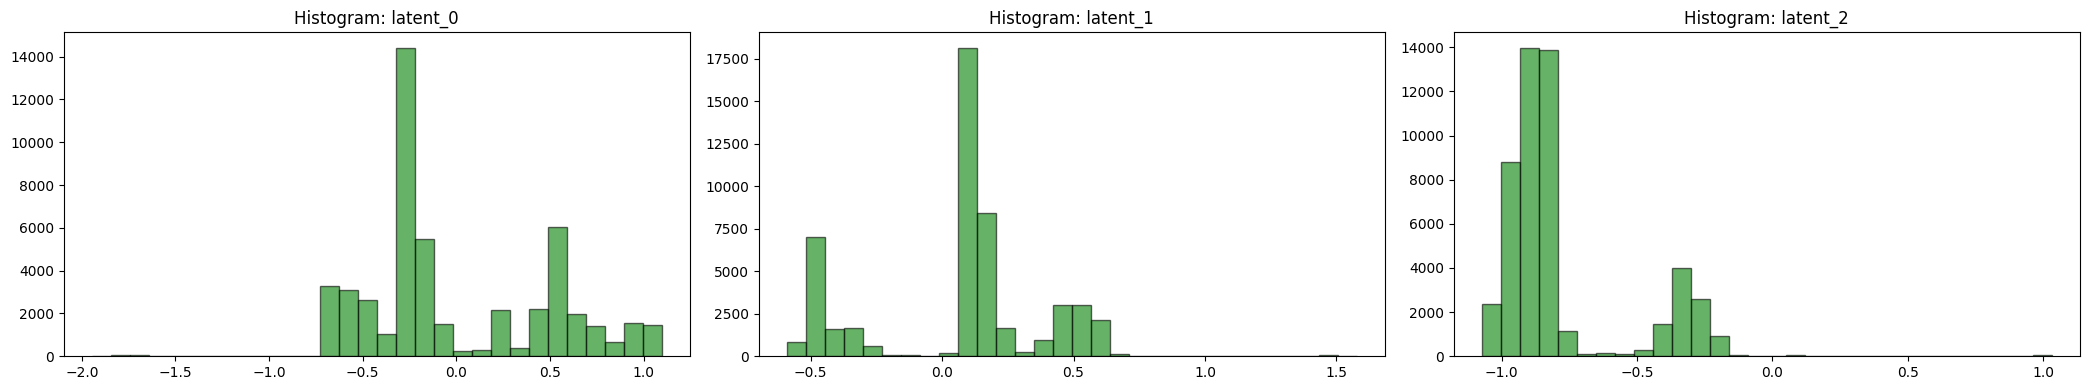

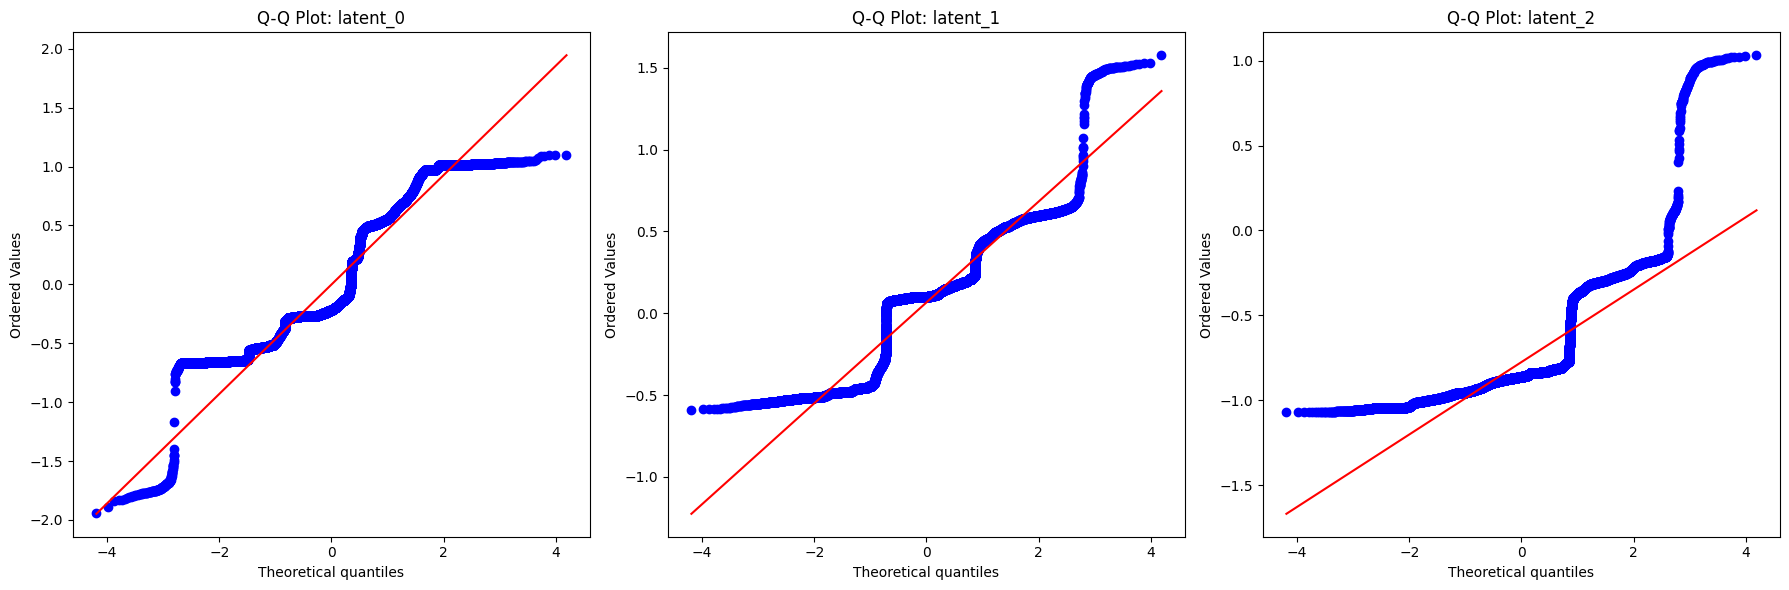

C:\Users\vihaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 50000.
  res = hypotest_fun_out(*samples, **kwds)


Normal columns (p >= 0.05): []
Normal columns (p >= 0.05): []


In [ ]:
run_variant_pipeline("full")

Found existing no_time_adv outputs; keeping them and skipping this variant.
Loading existing no_time_adv train data for Q-Q plots: c:\Users\vihaa\OneDrive\Documents\IPD-IDS\df_train_no_time_adv.csv
Normality check for variant: no_time_adv


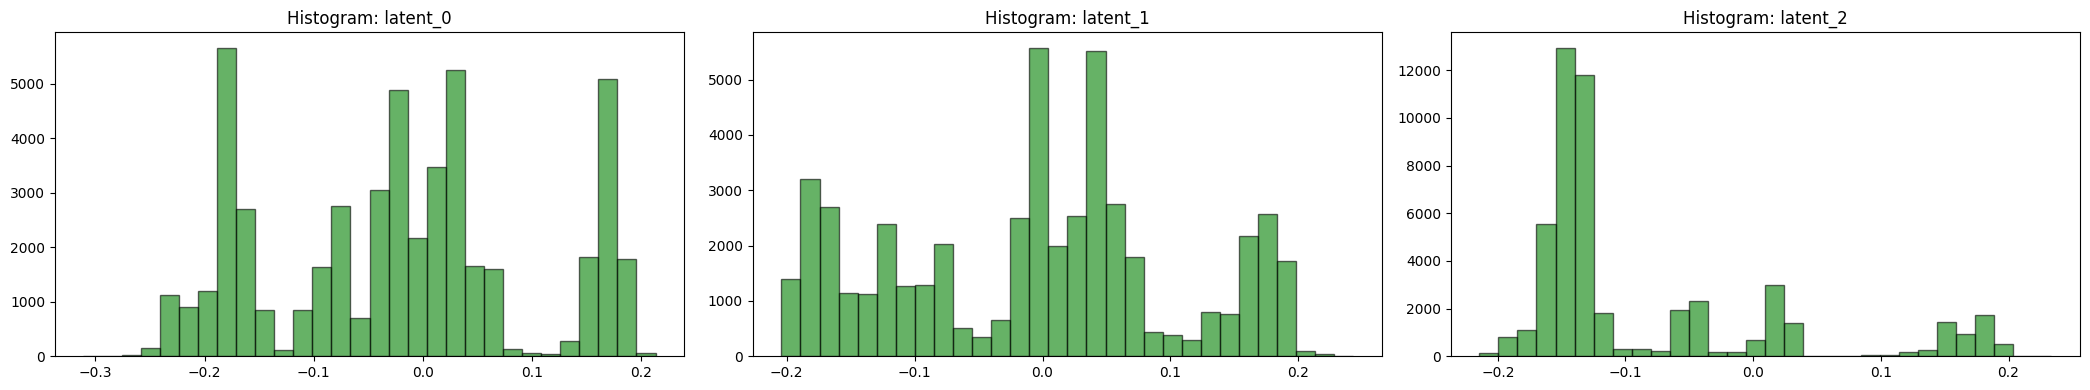

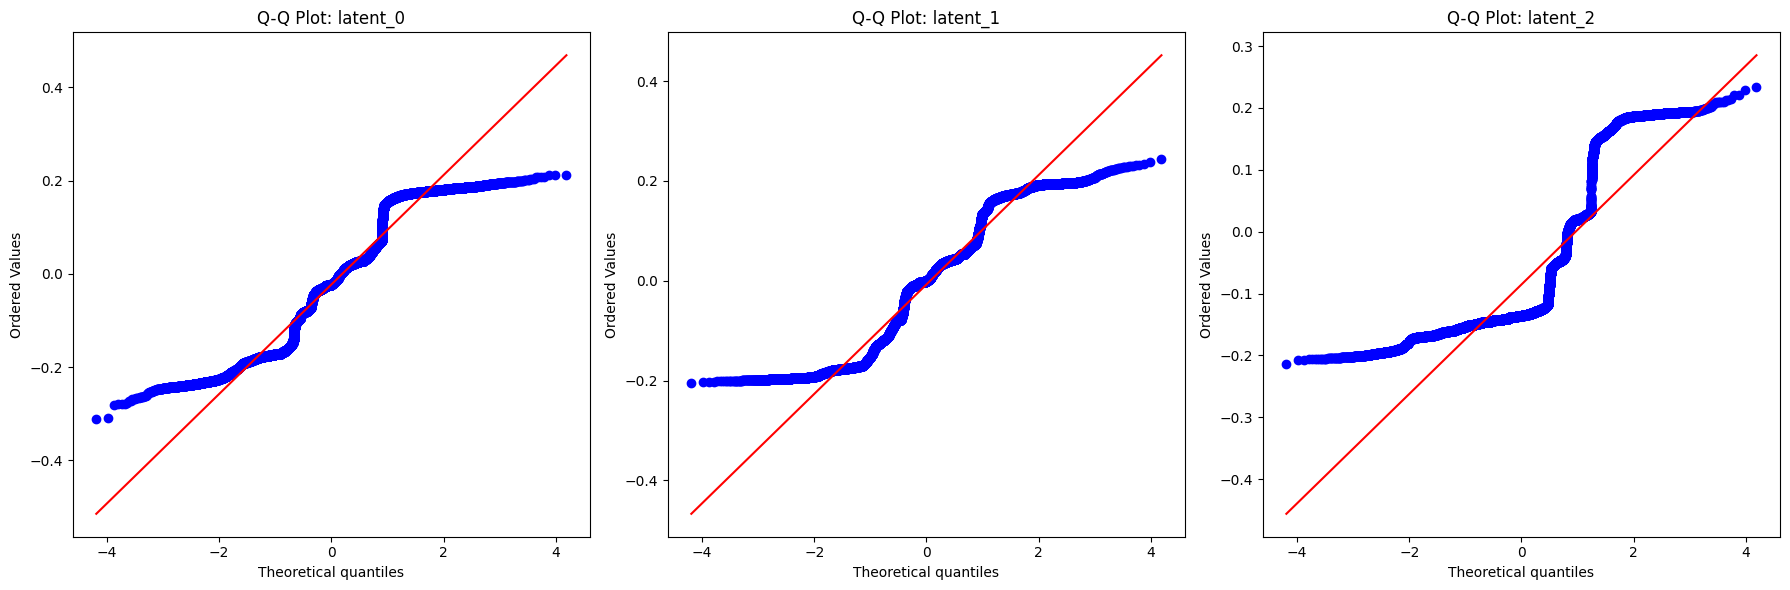

Normal columns (p >= 0.05): []
Normal columns (p >= 0.05): []


C:\Users\vihaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 50000.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
run_variant_pipeline("no_time_adv")

Missing no_student outputs; will train/generate this variant:
  - vae_no_student_model.pth
  - vae_training_history_no_student.csv
  - reconstruction_errors_no_student.npy
  - latent_norms_no_student.npy
  - df_train_no_student.csv
  - df_test_no_student.csv
  - df_sup_no_student.csv

Running variant: no_student
  time_adv=True  student_t=False
  ADV_LOSS_WEIGHT=0.2  TIME_BIN_ADV=0.2  DISC_STEPS=2
  RECON_STUDENT_WEIGHT=0.0  RECON_MSE_WEIGHT=1.0
Epoch 1/30  Train Loss: 77.5994 (Recon: 77.4532, MSE: 77.4532, KLD: 2.923692, Beta: 0.0500)  |  Val Loss: 46.0191 (Recon: 45.9163, MSE: 45.9163, KLD: 2.055284)  |  ChronAdv: 0.7623/1.3425  TimeBinAdv: 2.6113/1.8726  <-- best
LR: 0.000999
Epoch 2/30  Train Loss: 38.8361 (Recon: 38.5742, MSE: 38.5742, KLD: 2.618712, Beta: 0.1000)  |  Val Loss: 23.6886 (Recon: 23.4303, MSE: 23.4303, KLD: 2.582961)  |  ChronAdv: 0.8354/1.3033  TimeBinAdv: 2.4319/2.1505  <-- best
LR: 0.000996
Epoch 3/30  Train Loss: 18.2322 (Recon: 17.9239, MSE: 17.9239, KLD: 2.0556

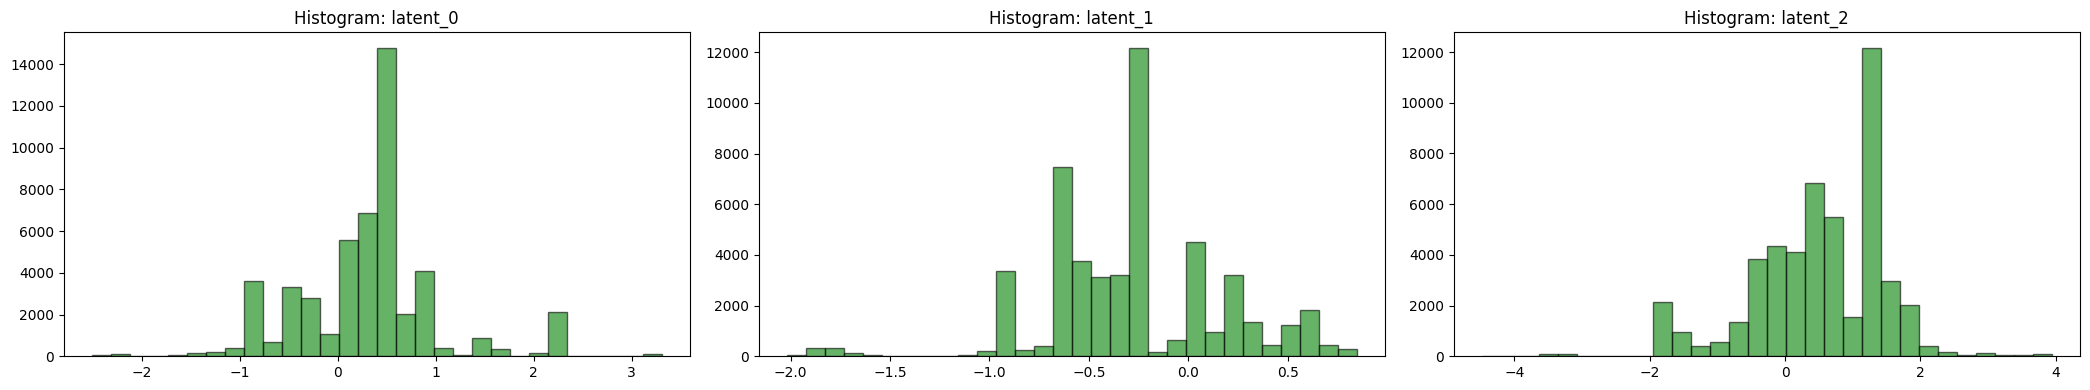

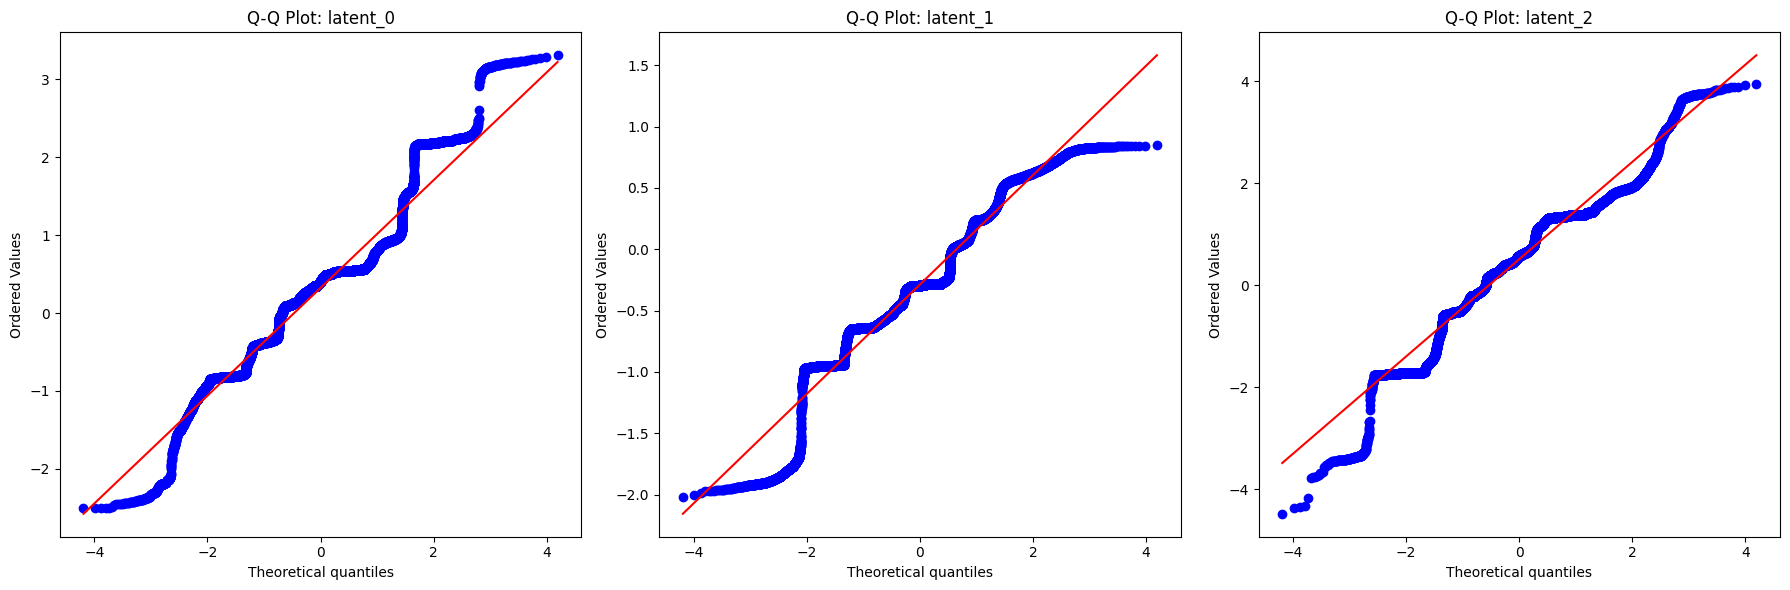

C:\Users\vihaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 50000.
  res = hypotest_fun_out(*samples, **kwds)


Normal columns (p >= 0.05): []
Normal columns (p >= 0.05): []
df_train saved to c:\Users\vihaa\OneDrive\Documents\IPD-IDS\df_train_no_student.csv (shape: (2097139, 9))
Test path: c:\Users\vihaa\OneDrive\Documents\IPD-IDS\combined_test.csv
df_test saved to c:\Users\vihaa\OneDrive\Documents\IPD-IDS\df_test_no_student.csv (shape: (1048555, 9))
Supplement path: c:\Users\vihaa\OneDrive\Documents\IPD-IDS\combined_supplement.csv
df_sup saved to c:\Users\vihaa\OneDrive\Documents\IPD-IDS\df_sup_no_student.csv (shape: (1048555, 9))


In [ ]:
run_variant_pipeline("no_student")